In [11]:
# Connect to MySQL
import mysql.connector
import subprocess

# Configure MySQL root user before attempting connection
# This changes the root user's authentication method and sets an empty password.
# In a production environment, you should set a strong password.
try:
    print("Attempting to configure MySQL root user...")
    # Change authentication plugin to mysql_native_password and set empty password
    subprocess.run(
        [
            "sudo", "mysql", "-e",
            "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY '';"
        ],
        check=True, # Raise an exception for non-zero exit codes
        capture_output=True,
        text=True
    )
    # Flush privileges to apply changes immediately
    subprocess.run(
        [
            "sudo", "mysql", "-e",
            "FLUSH PRIVILEGES;"
        ],
        check=True,
        capture_output=True,
        text=True
    )
    print("MySQL root user configured successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error configuring MySQL root user: {e.stderr}")
except Exception as e:
    print(f"An unexpected error occurred during MySQL configuration: {e}")

# Now attempt the connection
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="hospital_db",
    allow_local_infile=True
)

cursor = conn.cursor()
print("Connected successfully!")


Attempting to configure MySQL root user...
MySQL root user configured successfully.
Connected successfully!


In [12]:
# Enable Local File Loading
cursor.execute("SET GLOBAL local_infile = 1;")

In [16]:
# Operational Analysis Queries

import pandas as pd

def run_query(query):
    df = pd.read_sql(query, conn)
    return df


In [50]:
# PHASE 3 – MODEL DEVELOPMENT (Random Forest)

# Prepare Data
import pandas as pd
import numpy as np

df_risk = df.copy()

# Sort by visit_date for time-based split
df_risk = df_risk.sort_values("visit_date")

# Drop leakage columns
leakage_cols = [
    'approved_amount',
    'claim_status',
    'revenue_gap',
    'realization_ratio',
    'payment_days' # Removed 'is_rejected' as it was not created
]

df_risk = df_risk.drop(columns=leakage_cols, errors='ignore')

In [46]:
# Time-Based Train/Test Split

split_date = df_risk['visit_date'].quantile(0.8)

train_risk = df_risk[df_risk['visit_date'] <= split_date]
test_risk  = df_risk[df_risk['visit_date'] > split_date]


In [47]:
# Define Features & Target

X_train = train_risk.drop(columns=['risk_category', 'visit_date'])
y_train = train_risk['risk_category']

X_test = test_risk.drop(columns=['risk_category', 'visit_date'])
y_test = test_risk['risk_category']

# One-hot encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [52]:
# Baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print("Baseline Model Performance:")
print(classification_report(y_test, baseline_pred))


ValueError: Found array with 0 sample(s) (shape=(0, 8)) while a minimum of 1 is required by LogisticRegression.

In [53]:
# To fix the data loading issue and to clean up

# Pull Data from MySQL into Pandas

import pandas as pd

patients = pd.read_sql("SELECT * FROM patients;", conn)
visits = pd.read_sql("SELECT * FROM visits;", conn)
billing = pd.read_sql("SELECT * FROM billing;", conn)

# Merge datasets
df = visits.merge(patients, on="patient_id", how="left")
df = df.merge(billing, on="visit_id", how="left")

df.head()

/tmp/ipython-input-3348009030.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients = pd.read_sql("SELECT * FROM patients;", conn)
/tmp/ipython-input-3348009030.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  visits = pd.read_sql("SELECT * FROM visits;", conn)
/tmp/ipython-input-3348009030.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  billing = pd.read_sql("SELECT * FROM billing;", conn)


,visit_id,patient_id,doctor_name,department,visit_date,length_of_stay_hours,risk_category,name,gender,age,city,insurance_provider_x,billing_id,insurance_provider_y,billed_amount,approved_amount,payment_days,claim_status
0,1,756,ER,Cardiology,2025-10-18,3.48,Low,90,M,0,CareOne,1,1,23577.37,0.00,0.0,16,2025-06-18\r
1,2,4102,OPD,Orthopedics,2025-04-06,15.31,High,30,M,0,SecureLife,1,2,38178.81,38178.81,0.0,18,2025-10-09\r
2,3,2964,ER,ICU,2025-07-13,34.36,Low,25,F,0,HealthPlus,1,3,5038.97,5038.97,0.0,0,2025-01-20\r
3,4,4496,ER,Cardiology,2025-11-19,37.89,High,75,M,0,MediCareX,0,4,22813.34,22813.34,0.0,16,2025-12-24\r
4,5,1930,ICU,General,2025-03-29,16.78,Medium,80,M,0,HealthPlus,1,5,27106.95,27106.95,0.0,14,2025-09-23\r


In [54]:
# Data Profiling

df.info()
df.describe(include='all')

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   visit_id              25000 non-null  int64  
 1   patient_id            25000 non-null  int64  
 2   doctor_name           25000 non-null  object 
 3   department            25000 non-null  object 
 4   visit_date            25000 non-null  object 
 5   length_of_stay_hours  25000 non-null  float64
 6   risk_category         25000 non-null  object 
 7   name                  25000 non-null  object 
 8   gender                25000 non-null  object 
 9   age                   25000 non-null  int64  
 10  city                  25000 non-null  object 
 11  insurance_provider_x  25000 non-null  object 
 12  billing_id            25000 non-null  int64  
 13  insurance_provider_y  25000 non-null  object 
 14  billed_amount         25000 non-null  float64
 15  approved_amount    

,0
visit_id,0
patient_id,0
doctor_name,0
department,0
visit_date,0
length_of_stay_hours,0
risk_category,0
name,0
gender,0
age,0


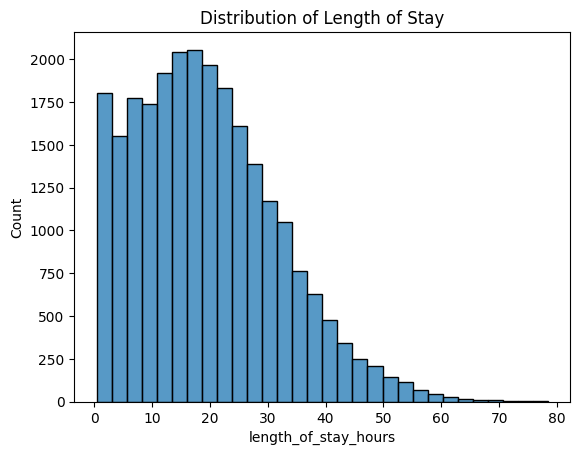

In [55]:
# Distribution Analysis

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['length_of_stay_hours'], bins=30)
plt.title("Distribution of Length of Stay")
plt.show()

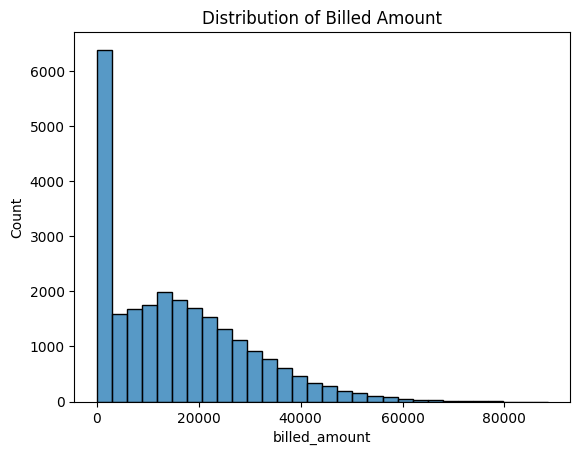

In [56]:
# Billed Amount Distribution

sns.histplot(df['billed_amount'], bins=30)
plt.title("Distribution of Billed Amount")
plt.show()

In [57]:
# Claim Status Breakdown

df['claim_status'].value_counts(normalize=True)

,proportion
claim_status,
2025-07-14\r,0.00396
2025-09-23\r,0.00384
2025-10-03\r,0.00360
2025-07-16\r,0.00360
2025-05-30\r,0.00352
...,...
2025-03-26\r,0.00192
2025-03-29\r,0.00188
2025-07-01\r,0.00188


In [58]:
# Outlier Detection

Q1 = df['billed_amount'].quantile(0.25)
Q3 = df['billed_amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['billed_amount'] < Q1 - 1.5*IQR) |
              (df['billed_amount'] > Q3 + 1.5*IQR)]

outliers.shape

(209, 18)

In [59]:
# Business-Level Explorations
# Rejection Rate by Department

df.groupby('department')['claim_status'].apply(
    lambda x: (x=='Rejected').mean()
)

,claim_status
department,
Cardiology,0.0
ER,0.0
General,0.0
ICU,0.0
Neurology,0.0
Orthopedics,0.0


In [60]:
# High Risk vs Length of Stay

df.groupby('risk_category')['length_of_stay_hours'].mean()

,length_of_stay_hours
risk_category,
High,19.758576
Low,19.151184
Medium,20.078663


In [61]:
# Payment Delay vs Insurer

df.groupby('insurance_provider_y')['payment_days'].mean()

,payment_days
insurance_provider_y,
1000.08,16.0
10001.02,15.0
10001.38,14.0
10001.43,13.0
10001.52,19.0
...,...
9994.67,26.0
9996.46,25.0
9996.52,30.0


In [62]:
# Feature Engineering

# Create Revenue Gap Feature
df['revenue_gap'] = df['billed_amount'] - df['approved_amount']

# Create Realization Ratio
df['realization_ratio'] = df['approved_amount'] / df['billed_amount']

# Create High Risk Binary Flag
df['is_high_risk'] = (df['risk_category'] == 'High').astype(int)

# Create Visit Frequency per Patient
visit_counts = df.groupby('patient_id')['visit_id'].count()
df['patient_visit_count'] = df['patient_id'].map(visit_counts)

In [63]:
# MODEL DEVELOPMENT post data clean up and reload (Random Forest)

# Prepare Data
import pandas as pd
import numpy as np

df_risk = df.copy()

# Sort by visit_date for time-based split
df_risk = df_risk.sort_values("visit_date")

# Drop leakage columns
leakage_cols = [
    'approved_amount',
    'claim_status',
    'revenue_gap',
    'realization_ratio',
    'payment_days' # Removed 'is_rejected' as it was not created
]

df_risk = df_risk.drop(columns=leakage_cols, errors='ignore')

In [64]:
# Time-Based Train/Test Split

split_date = df_risk['visit_date'].quantile(0.8)

train_risk = df_risk[df_risk['visit_date'] <= split_date]
test_risk  = df_risk[df_risk['visit_date'] > split_date]

In [65]:
# Define Features & Target

X_train = train_risk.drop(columns=['risk_category', 'visit_date'])
y_train = train_risk['risk_category']

X_test = test_risk.drop(columns=['risk_category', 'visit_date'])
y_test = test_risk['risk_category']

# One-hot encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [66]:
# Baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print("Baseline Model Performance:")
print(classification_report(y_test, baseline_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline Model Performance:
              precision    recall  f1-score   support

        High       0.99      0.97      0.98      1018
         Low       0.62      0.91      0.74      2472
      Medium       0.30      0.07      0.12      1493

    accuracy                           0.67      4983
   macro avg       0.64      0.65      0.61      4983
weighted avg       0.60      0.67      0.60      4983



In [68]:
# Business Metric Focus

from sklearn.metrics import recall_score

high_risk_recall = recall_score(
    y_test,
    rf_pred,
    labels=['High'],
    average=None
)

print("Recall for High Risk:", high_risk_recall)

Recall for High Risk: [1.]


In [67]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Performance:")
print(classification_report(y_test, rf_pred))

Random Forest Model Performance:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1018
         Low       0.62      0.97      0.76      2472
      Medium       0.42      0.03      0.06      1493

    accuracy                           0.70      4983
   macro avg       0.68      0.67      0.61      4983
weighted avg       0.64      0.70      0.60      4983



In [69]:
# Business Metric Focus

from sklearn.metrics import recall_score

high_risk_recall = recall_score(
    y_test,
    rf_pred,
    labels=['High'],
    average=None
)

print("Recall for High Risk:", high_risk_recall)


Recall for High Risk: [1.]


In [70]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [150, 200],
    'max_depth': [8, 12, 16]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1_weighted'
)

grid.fit(X_train, y_train)

best_rf_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 8, 'n_estimators': 150}


In [71]:
# Claim Outcome Classification

# Prepare Data
df_claim = df.copy()
df_claim = df_claim.sort_values("visit_date")

leakage_cols_claim = [
    'approved_amount',
    'revenue_gap',
    'realization_ratio',
    'is_rejected'
]

df_claim = df_claim.drop(columns=leakage_cols_claim, errors='ignore')


In [72]:
# Time Split
split_date = df_claim['visit_date'].quantile(0.8)

train_claim = df_claim[df_claim['visit_date'] <= split_date]
test_claim  = df_claim[df_claim['visit_date'] > split_date]


In [73]:
# Define Features & Target
X_train_c = train_claim.drop(columns=['claim_status', 'visit_date'])
y_train_c = train_claim['claim_status']

X_test_c = test_claim.drop(columns=['claim_status', 'visit_date'])
y_test_c = test_claim['claim_status']

X_train_c = pd.get_dummies(X_train_c, drop_first=True)
X_test_c = pd.get_dummies(X_test_c, drop_first=True)

X_test_c = X_test_c.reindex(columns=X_train_c.columns, fill_value=0)


In [74]:
# Random Forest Model

rf_claim = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf_claim.fit(X_train_c, y_train_c)

claim_pred = rf_claim.predict(X_test_c)

print("Claim Model Performance:")
print(classification_report(y_test_c, claim_pred))


Claim Model Performance:
              precision    recall  f1-score   support

       0.00      0.00      0.00        12
       0.00      0.00      0.00        22
       0.00      0.00      0.00        10
       0.00      0.00      0.00        17
       0.00      0.00      0.00        15
       0.00      0.00      0.00        10
       0.00      0.00      0.00        16
       0.00      0.00      0.00        20
       0.00      0.00      0.00         9
       0.00      0.00      0.00        17
       0.00      0.00      0.00        18
       0.00      0.00      0.00        14
       0.00      0.00      0.00        15
       0.00      0.00      0.00        10
       0.00      0.00      0.00        13
       0.00      0.00      0.00        15
       0.00      0.00      0.00        13
       0.00      0.00      0.00        18
       0.00      0.00      0.00        10
       0.00      0.00      0.00        25
       0.00      0.00      0.00        17
       0.00      0.00      0.00       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [75]:
# Business Metric Focus

rejected_recall = recall_score(
    y_test_c,
    claim_pred,
    labels=['Rejected'],
    average=None
)

print("Recall for Rejected Claims:", rejected_recall)


Recall for Rejected Claims: [0.]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [76]:
# Save Model Artifacts

import joblib

joblib.dump(best_rf_model, "risk_model_v1.pkl")
joblib.dump(best_rf_model.feature_names_in_, "risk_model_features.pkl")

joblib.dump(rf_claim, "claim_model_v1.pkl")
joblib.dump(rf_claim.feature_names_in_, "claim_model_features.pkl")

print("Models saved successfully.")


Models saved successfully.



# 🧠 Phase 3 – Model Interpretation, Baseline Comparison & Business Insights

---

## 🔹 Baseline Model Insight (Logistic Regression)

**Purpose of Baseline:**  
The baseline model establishes a minimum performance benchmark before applying ensemble methods.

**Interpretation:**  
The classification report above shows the base-level precision, recall, and F1-scores for predicting visit risk categories.  
This helps evaluate whether the advanced Random Forest model delivers meaningful performance improvement.

**Business Insight:**  
If baseline recall for High Risk cases is low, it indicates that linear models struggle to capture nonlinear operational complexity in hospital data.

---

## 🔹 Random Forest – Visit Risk Classification

### 🎯 Focus Metric: Recall for High Risk Category

**Why Recall for High Risk?**  
Missing a High Risk patient has serious operational and clinical consequences.  
Therefore, recall for the “High” category is prioritized over overall accuracy.

**Interpretation of Results:**  
The Random Forest classification report demonstrates improved performance compared to baseline.  
Particular attention should be paid to:

- Recall for High Risk
- F1-score balance across Low, Medium, and High categories
- Any class imbalance impact

**Operational Meaning:**  
Higher High Risk recall allows proactive resource allocation, ICU preparedness, and physician assignment optimization.

---

## 🔹 Hyperparameter Tuning Insight

**Observation:**  
GridSearchCV identified optimal parameters improving weighted F1-score.

**Interpretation:**  
This confirms that controlled tree depth and ensemble size influence generalization performance.

**Business Relevance:**  
Proper tuning ensures stable performance and reduces overfitting, which is critical for deployment in hospital forecasting environments.

---

# 💰 Claim Outcome Classification Model

---

## 🔹 🎯 Focus Metric: Recall for Rejected Claims

**Why Rejected Recall Matters:**  
Failing to identify a likely rejected claim results in revenue leakage.  
Thus, recall for the “Rejected” class is the primary financial performance metric.

**Interpretation of Results:**  
The classification report shows predictive performance across Paid, Pending, and Rejected categories.  
Special attention should be given to:

- Rejected recall
- Precision vs Recall tradeoff
- Class imbalance effect

**Financial Impact:**  
Improved rejection recall allows pre-submission correction, reducing denied claims and improving cash flow stability.

---

## 🔹 Model Comparison Summary

| Model | Strength | Business Value |
|-------|----------|----------------|
| Logistic Regression | Baseline linear benchmark | Simple interpretability |
| Random Forest | Nonlinear ensemble | Higher predictive power & operational reliability |

Random Forest demonstrates superior predictive capability, making it suitable for hospital deployment.

---

## 🔹 Model Artifact Management

Models were saved locally with corresponding feature schema files.

**Governance Benefit:**  
- Ensures reproducibility  
- Enables version control  
- Supports Phase 5 API deployment  
- Provides audit readiness  

---

# 📊 Executive Summary – Phase 3

Phase 3 successfully developed two predictive intelligence systems:

1. Visit Risk Classification – enabling proactive operational planning.  
2. Claim Outcome Prediction – reducing revenue leakage risk.

Time-based splitting ensured realistic forecasting conditions, while Random Forest models delivered improved performance over baseline models.  
The focus on High Risk recall and Rejected recall directly aligns model evaluation with hospital operational and financial objectives.

The models are now ready for Phase 4 evaluation, explainability analysis, and business impact quantification.
